In [7]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os
import os, sys
import torch
import numpy as np

In [8]:
    
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, maxDomain_0, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    maxDomain[0] = maxDomain_0
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    # print(f"dx = {dx}, dy = {dy}, h = {h}")
    # print(f"nx = {nx}, ny = {ny}")
    # print(f"minDomain = {minDomain}, maxDomain = {maxDomain}")
    # print(f"periodicity = {periodicity}")
    # print(f"dim = {dim}")
    # print(f"device = {device}")
    # print(f"maxDomain_0 = {maxDomain_0}")
    # print(f"targetNumNeighbors = {targetNumNeighbors}")
    

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    ypositions = []
    for d in range(dim):
        ypositions.append(torch.linspace(-0.5 + dy / 2, 0.5 - dy / 2, ny, device = device))
    grid = torch.meshgrid(*ypositions, indexing = 'xy')
    y = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    ySupport = torch.ones(y.shape[0], device = device) * volumeToSupport(dy**dim, targetNumNeighbors, dim)
    return (y, positions), (ySupport, supports), (minDomain, maxDomain), periodicity, positions.shape[0]

In [10]:

from typing import NamedTuple, Union
from typing import NamedTuple

from dataclasses import dataclass
# @torch.jit.script
@dataclass(slots=True)
class DomainDescription:
    """
    A named tuple containing the minimum and maximum domain values.
    """
    min: torch.Tensor
    max: torch.Tensor
    periodic: torch.Tensor
    dim: int

    def __ne__(self, other: 'DomainDescription') -> bool:
        return not self.__eq__(other)
    
# @torch.jit.script
@dataclass#(slots=True)
class PointCloud:
    """
    A named tuple containing the positions of the particles and the number of particles.
    """
    positions: torch.Tensor
    supports: torch.Tensor

    def __ne__(self, other: 'PointCloud') -> bool:
        return not self.__eq__(other)


In [14]:

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
targetNumNeighbors = 50
hashMapLength = 4096
nx = 32
dim = 2
periodic = False
(y, x), (ySupport, xSupport), (minDomain, maxDomain), periodicity, hashMapLength = generateNeighborTestData(nx, targetNumNeighbors, dim, 1.0, False, device)
h = ySupport[0].cpu().item()

# from torchCompactRadius.util import DomainDescription, PointCloud

minDomain *= 2
maxDomain *= 2
domainDescription = DomainDescription(minDomain, maxDomain, periodicity, dim)

pointCloudX = PointCloud(x, xSupport)
pointCloudY = PointCloud(y, ySupport)

# pointCloudX = PointCloud(x, None)
# pointCloudY = PointCloud(y, None)

[X] Min Supports: 0.24933892488479614, Max Supports: 0.24933892488479614
[Y] Min Supports: 0.16622595489025116, Max Supports: 0.16622595489025116


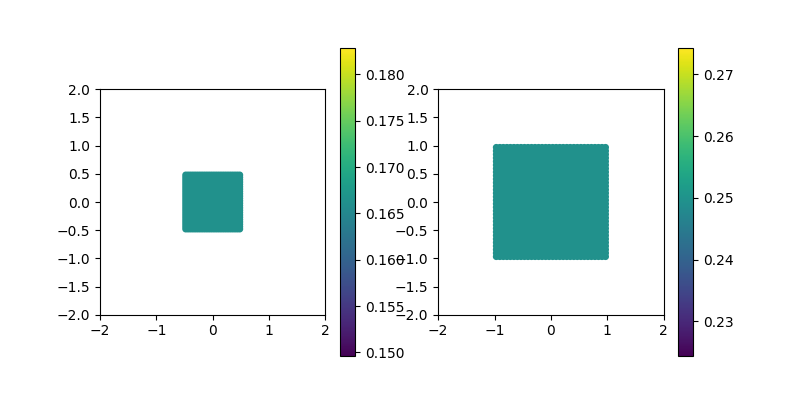

In [15]:
pointCloudX.supports = xSupport #+ torch.randn_like(xSupport) * xSupport.max() / 16 + (1 - torch.linalg.norm(x, dim = -1))**2 * xSupport.max() * 8
pointCloudY.supports = ySupport #+ torch.randn_like(ySupport) * ySupport.max() / 16 + (1 - torch.linalg.norm(y, dim = -1))**2 * xSupport.min() * 4 - 0.125

pointCloudX.supports = pointCloudX.supports.clamp(max = (domainDescription.max - domainDescription.min).min() / 4 -1e-3)
pointCloudY.supports = pointCloudY.supports.clamp(max = (domainDescription.max - domainDescription.min).min() / 4 -1e-3)

import matplotlib.pyplot as plt
fig, axis = plt.subplots(1,2, figsize = (8,4), squeeze=False)

sc = axis[0,0].scatter(y[:,0].cpu(), y[:,1].cpu(), s = 16, c = pointCloudY.supports.cpu().numpy())
fig.colorbar(sc, ax = axis[0,0])
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,0].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())

sc = axis[0,1].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 16, c = pointCloudX.supports.cpu().numpy())
fig.colorbar(sc, ax = axis[0,1])
axis[0,1].set_aspect('equal')
axis[0,1].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,1].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())

print(f'[X] Min Supports: {pointCloudX.supports.min()}, Max Supports: {pointCloudX.supports.max()}')
print(f'[Y] Min Supports: {pointCloudY.supports.min()}, Max Supports: {pointCloudY.supports.max()}')


In [16]:
from typing import Optional, List
import torch

@torch.jit.script
def mod(x, min : float, max : float):
    return torch.where(torch.abs(x) > (max - min) / 2, torch.sgn(x) * ((torch.abs(x) + min) % (max - min) + min), x)
    
@torch.jit.script
def radiusNaive(x, y, hx, hy, periodic : Optional[torch.Tensor] = None, minDomain = None, maxDomain = None, mode : str = 'gather'):
    periodicity = torch.tensor([False] * x.shape[1], dtype = torch.bool, device = x.device) if periodic is None else periodic
    
    pos_x = torch.stack([x[:,i] if not periodic_i else torch.remainder(x[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    pos_y = torch.stack([y[:,i] if not periodic_i else torch.remainder(y[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    
    distanceMatrices = torch.stack([pos_x[:,i] - pos_y[:,i,None] if not periodic_i else mod(pos_x[:,i] - pos_y[:,i,None], minDomain[i], maxDomain[i]) for i, periodic_i in enumerate(periodicity)], dim = -1)
    distanceMatrix = torch.sqrt(torch.sum(distanceMatrices**2, dim = -1))
    
    indexI, indexJ = torch.meshgrid(torch.arange(x.shape[0]).to(x.device), torch.arange(y.shape[0]).to(y.device), indexing = 'xy')
    if mode == 'gather':        
        gatherMatrix = hx.repeat(y.shape[0],1)
        adjacencyDense = distanceMatrix <= gatherMatrix
        # supports = gatherMatrix[adjacencyDense]
    elif mode == 'scatter':        
        scatterMatrix = hy.repeat(x.shape[0],1).mT
        adjacencyDense = distanceMatrix <= scatterMatrix
        # supports = scatterMatrix[adjacencyDense]
    elif mode == 'symmetric':
        symmetricMatrix = (hx + hy[:,None]) / 2
        adjacencyDense = distanceMatrix <= symmetricMatrix
    elif mode == 'superSymmetric':
        symmetricMatrix = torch.max(hx, hy)
        adjacencyDense = distanceMatrix <= symmetricMatrix
    else:
        raise ValueError('mode must be one of gather, scatter, symmetric, or superSymmetric')
        # supports = symmetricMatrix[adjacencyDense]
    
    ii = indexI[adjacencyDense]
    jj = indexJ[adjacencyDense]

    return ii, jj#, distanceMatrix[adjacencyDense], distanceMatrices[adjacencyDense], supports

@torch.jit.script
def radiusNaiveFixed(x, y, h : torch.Tensor, periodic : Optional[torch.Tensor] = None, minDomain = None, maxDomain = None):
    periodicity = torch.tensor([False] * x.shape[1], dtype = torch.bool, device = x.device) if periodic is None else periodic
    
    pos_x = torch.stack([x[:,i] if not periodic_i else torch.remainder(x[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    pos_y = torch.stack([y[:,i] if not periodic_i else torch.remainder(y[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    
    distanceMatrices = torch.stack([pos_x[:,i] - pos_y[:,i,None] if not periodic_i else mod(pos_x[:,i] - pos_y[:,i,None], minDomain[i], maxDomain[i]) for i, periodic_i in enumerate(periodicity)], dim = -1)
    distanceMatrix = torch.sum(distanceMatrices**2, dim = -1)
    
    indexI, indexJ = torch.meshgrid(torch.arange(x.shape[0]).to(x.device), torch.arange(y.shape[0]).to(y.device), indexing = 'xy')
    adjacencyDense = distanceMatrix <= h**2
    
    ii = indexI[adjacencyDense]
    jj = indexJ[adjacencyDense]

    return ii, jj#, distanceMatrix[adjacencyDense], distanceMatrices[adjacencyDense], supports

In [17]:
i,j = radiusNaive(x, y, pointCloudX.supports, pointCloudY.supports, periodicity, domainDescription.min, domainDescription.max, mode = 'gather')

In [22]:
ii, ni_ = torch.unique(i, return_counts = True)
ni = torch.zeros(x.shape[0], dtype = torch.int64, device = x.device)
ni[ii] = ni_
jj, nj_ = torch.unique(j, return_counts = True)
nj = torch.zeros(y.shape[0], dtype = torch.int64, device = x.device)

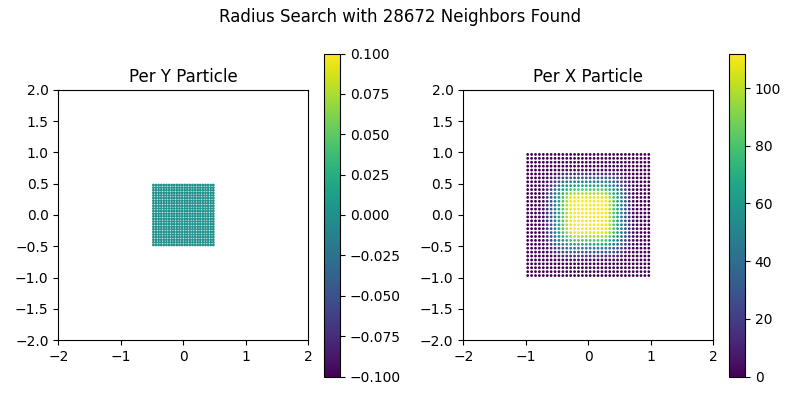

In [26]:
fig, axis = plt.subplots(1,2, figsize = (8,4), squeeze=False)
sc = axis[0,0].scatter(y[:,0].cpu(), y[:,1].cpu(), s = 1, c = nj.cpu().numpy())
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,0].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,0].set_title('Per Y Particle')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 1, c = ni.cpu().numpy())
axis[0,1].set_aspect('equal')
axis[0,1].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,1].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,1].set_title('Per X Particle')

fig.colorbar(sc, ax = axis[0,1])

fig.suptitle(f'Radius Search with {i.shape[0]} Neighbors Found')
fig.tight_layout()

In [29]:
# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

@wp.kernel
def warp_radius_search_kernel(
    x: wp.array(dtype=wp.vec2f),           # Query points
    y: wp.array(dtype=wp.vec2f),           # Reference points
    hx: wp.array(dtype=wp.float32),        # Query radii
    hy: wp.array(dtype=wp.float32),        # Reference radii
    min_domain: wp.vec2f,                  # Domain minimum
    max_domain: wp.vec2f,                  # Domain maximum
    periodic: wp.array(dtype=wp.bool),     # Periodicity per dimension
    mode: wp.uint32,                       # 0=gather, 1=scatter, 2=symmetric, 3=superSymmetric
    edge_count: wp.array(dtype=wp.int32),  # Output: number of edges
):
    """
    Warp kernel for computing radius search neighbors.
    Writes to a global counter for the number of valid neighbors found.
    """
    # Process pairs (i, j) in parallel
    i = wp.tid()
    
    if i < wp.len(x):
        count = int(0)
        
        for j in range(wp.len(y)):
            # Get positions
            xi = x[i]
            yj = y[j]
            
            # Handle periodic boundary conditions
            if periodic[0]:
                dx = xi[0] - yj[0]
                domain_size = max_domain[0] - min_domain[0]
                if wp.abs(dx) > domain_size / 2.0:
                    dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
            else:
                dx = xi[0] - yj[0]
            
            if periodic[1]:
                dy = xi[1] - yj[1]
                domain_size = max_domain[1] - min_domain[1]
                if wp.abs(dy) > domain_size / 2.0:
                    dy = wp.sign(dy) * (wp.abs(dy) - domain_size)
            else:
                dy = xi[1] - yj[1]
            
            # Compute distance
            dist_sq = dx * dx + dy * dy
            dist = wp.sqrt(dist_sq)
            
            # Determine threshold based on mode
            threshold = 0.0
            if mode == 0:  # gather
                threshold = hx[i]
            elif mode == 1:  # scatter
                threshold = hy[j]
            elif mode == 2:  # symmetric
                threshold = (hx[i] + hy[j]) / 2.0
            elif mode == 3:  # superSymmetric
                threshold = wp.max(hx[i], hy[j])
            
            # Count valid neighbors
            if dist <= threshold:
                count += 1
        
        edge_count[i] = count


@wp.kernel
def warp_radius_search_collect_kernel(
    x: wp.array(dtype=wp.vec2f),           # Query points
    y: wp.array(dtype=wp.vec2f),           # Reference points
    hx: wp.array(dtype=wp.float32),        # Query radii
    hy: wp.array(dtype=wp.float32),        # Reference radii
    min_domain: wp.vec2f,                  # Domain minimum
    max_domain: wp.vec2f,                  # Domain maximum
    periodic: wp.array(dtype=wp.bool),     # Periodicity per dimension
    mode: wp.uint32,                       # 0=gather, 1=scatter, 2=symmetric, 3=superSymmetric
    edge_offsets: wp.array(dtype=wp.int32), # Cumulative edge counts
    edge_i: wp.array(dtype=wp.int32),      # Output: query point indices
    edge_j: wp.array(dtype=wp.int32),      # Output: reference point indices
):
    """
    Warp kernel to collect the actual neighbor pairs.
    """
    i = wp.tid()
    
    if i < wp.len(x):
        offset = edge_offsets[i]
        edge_idx = offset
        
        for j in range(wp.len(y)):
            # Get positions
            xi = x[i]
            yj = y[j]
            
            # Handle periodic boundary conditions
            if periodic[0]:
                dx = xi[0] - yj[0]
                domain_size = max_domain[0] - min_domain[0]
                if wp.abs(dx) > domain_size / 2.0:
                    dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
            else:
                dx = xi[0] - yj[0]
            
            if periodic[1]:
                dy = xi[1] - yj[1]
                domain_size = max_domain[1] - min_domain[1]
                if wp.abs(dy) > domain_size / 2.0:
                    dy = wp.sign(dy) * (wp.abs(dy) - domain_size)
            else:
                dy = xi[1] - yj[1]
            
            # Compute distance
            dist_sq = dx * dx + dy * dy
            dist = wp.sqrt(dist_sq)
            
            # Determine threshold based on mode
            threshold = 0.0
            if mode == 0:  # gather
                threshold = hx[i]
            elif mode == 1:  # scatter
                threshold = hy[j]
            elif mode == 2:  # symmetric
                threshold = (hx[i] + hy[j]) / 2.0
            elif mode == 3:  # superSymmetric
                threshold = wp.max(hx[i], hy[j])
            
            # Store valid neighbors
            if dist <= threshold:
                edge_i[edge_idx] = i
                edge_j[edge_idx] = j
                edge_idx += 1


def radius_search_warp(x_np, y_np, hx_np, hy_np, periodic_np, min_domain_np, max_domain_np, mode='gather'):
    """
    Radius search using NVIDIA Warp.
    
    Args:
        x_np: Query point positions (numpy array, Nx2)
        y_np: Reference point positions (numpy array, Mx2)
        hx_np: Query support radii (numpy array, N)
        hy_np: Reference support radii (numpy array, M)
        periodic_np: Periodicity flags (numpy array, 2)
        min_domain_np: Domain minimum (numpy array, 2)
        max_domain_np: Domain maximum (numpy array, 2)
        mode: One of 'gather', 'scatter', 'symmetric', 'superSymmetric'
    
    Returns:
        Tuple of (neighbor_i, neighbor_j) as torch tensors
    """
    # Convert mode string to uint
    mode_map = {'gather': 0, 'scatter': 1, 'symmetric': 2, 'superSymmetric': 3}
    mode_uint = mode_map.get(mode, 0)
    
    # Convert numpy arrays to Warp arrays
    x_warp = wp.from_numpy(x_np.astype(np.float32))
    y_warp = wp.from_numpy(y_np.astype(np.float32))
    hx_warp = wp.from_numpy(hx_np.astype(np.float32))
    hy_warp = wp.from_numpy(hy_np.astype(np.float32))
    periodic_warp = wp.from_numpy(periodic_np.astype(bool))
    min_domain_warp = wp.vec2f(float(min_domain_np[0]), float(min_domain_np[1]))
    max_domain_warp = wp.vec2f(float(max_domain_np[0]), float(max_domain_np[1]))
    
    # First pass: count edges per query point
    edge_count = wp.zeros(len(x_np), dtype=wp.int32)
    wp.launch(warp_radius_search_kernel, dim=len(x_np), inputs=[
        x_warp, y_warp, hx_warp, hy_warp, min_domain_warp, max_domain_warp, 
        periodic_warp, wp.uint32(mode_uint), edge_count
    ])
    
    # Convert counts to host
    edge_count_np = edge_count.numpy()
    total_edges = int(np.sum(edge_count_np))
    
    # Compute cumulative offsets
    edge_offsets = np.zeros(len(x_np), dtype=np.int32)
    edge_offsets[1:] = np.cumsum(edge_count_np[:-1])
    edge_offsets_warp = wp.from_numpy(edge_offsets)
    
    # Allocate output arrays
    edge_i = wp.zeros(total_edges, dtype=wp.int32)
    edge_j = wp.zeros(total_edges, dtype=wp.int32)
    
    # Second pass: collect edges
    wp.launch(warp_radius_search_collect_kernel, dim=len(x_np), inputs=[
        x_warp, y_warp, hx_warp, hy_warp, min_domain_warp, max_domain_warp,
        periodic_warp, wp.uint32(mode_uint), edge_offsets_warp, edge_i, edge_j
    ])
    
    # Convert back to torch tensors
    i_torch = torch.from_numpy(edge_i.numpy()).to(device)
    j_torch = torch.from_numpy(edge_j.numpy()).to(device)
    
    return i_torch, j_torch


# Test the Warp implementation
print("Testing Warp-based Radius Search Implementation...")
i_warp, j_warp = radius_search_warp(
    x.cpu().numpy(), 
    y.cpu().numpy(), 
    pointCloudX.supports.cpu().numpy(), 
    pointCloudY.supports.cpu().numpy(), 
    periodicity.cpu().numpy(), 
    domainDescription.min.cpu().numpy(), 
    domainDescription.max.cpu().numpy(), 
    mode='gather'
)

print(f"Warp implementation found {i_warp.shape[0]} neighbors")
print(f"Torch implementation found {i.shape[0]} neighbors")
print(f"Results match: {torch.allclose(i.sort()[0], i_warp.sort()[0].to(i.dtype)) and torch.allclose(j.sort()[0], j_warp.sort()[0].to(j.dtype))}")


Testing Warp-based Radius Search Implementation...
Warp implementation found 28672 neighbors
Torch implementation found 28672 neighbors
Results match: True


In [30]:
# Alternative: Matrix-based Warp Implementation (Explicit Matrix Version)
# This version creates full distance matrices like the naive search, less efficient but more explicit

@wp.kernel
def warp_compute_distance_matrix_kernel(
    x: wp.array(dtype=wp.vec2f),           # Query points (N)
    y: wp.array(dtype=wp.vec2f),           # Reference points (M)
    min_domain: wp.vec2f,                  # Domain minimum
    max_domain: wp.vec2f,                  # Domain maximum
    periodic: wp.array(dtype=wp.bool),     # Periodicity per dimension
    distance_matrix: wp.array(dtype=wp.float32),  # Output: NxM distance matrix
):
    """
    Compute full NxM distance matrix with periodic boundary conditions.
    """
    # Linear index maps to (i, j) pair
    idx = wp.tid()
    N = wp.len(x)
    M = wp.len(y)
    
    if idx < N * M:
        i = idx // M
        j = idx % M
        
        xi = x[i]
        yj = y[j]
        
        # Handle periodic boundary conditions
        if periodic[0]:
            dx = xi[0] - yj[0]
            domain_size = max_domain[0] - min_domain[0]
            if wp.abs(dx) > domain_size / 2.0:
                dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
        else:
            dx = xi[0] - yj[0]
        
        if periodic[1]:
            dy = xi[1] - yj[1]
            domain_size = max_domain[1] - min_domain[1]
            if wp.abs(dy) > domain_size / 2.0:
                dy = wp.sign(dy) * (wp.abs(dy) - domain_size)
        else:
            dy = xi[1] - yj[1]
        
        # Compute distance
        dist = wp.sqrt(dx * dx + dy * dy)
        distance_matrix[i * M + j] = dist


@wp.kernel
def warp_adjacency_kernel(
    distance_matrix: wp.array(dtype=wp.float32),  # NxM distance matrix
    hx: wp.array(dtype=wp.float32),        # Query radii (N)
    hy: wp.array(dtype=wp.float32),        # Reference radii (M)
    mode: wp.uint32,                       # 0=gather, 1=scatter, 2=symmetric, 3=superSymmetric
    adjacency_matrix: wp.array(dtype=wp.bool),    # Output: NxM adjacency matrix
):
    """
    Compute adjacency matrix by comparing distances to support radii.
    """
    idx = wp.tid()
    N = wp.len(hx)
    M = wp.len(hy)
    
    if idx < N * M:
        i = idx // M
        j = idx % M
        dist = distance_matrix[i * M + j]
        
        # Determine threshold based on mode
        threshold = 0.0
        if mode == 0:  # gather
            threshold = hx[i]
        elif mode == 1:  # scatter
            threshold = hy[j]
        elif mode == 2:  # symmetric
            threshold = (hx[i] + hy[j]) / 2.0
        elif mode == 3:  # superSymmetric
            threshold = wp.max(hx[i], hy[j])
        
        adjacency_matrix[i * M + j] = dist <= threshold


def radius_search_warp_matrix(x_np, y_np, hx_np, hy_np, periodic_np, min_domain_np, max_domain_np, mode='gather'):
    """
    Radius search using NVIDIA Warp with explicit matrix approach (less efficient but matches naive implementation).
    
    Args:
        x_np: Query point positions (numpy array, Nx2)
        y_np: Reference point positions (numpy array, Mx2)
        hx_np: Query support radii (numpy array, N)
        hy_np: Reference support radii (numpy array, M)
        periodic_np: Periodicity flags (numpy array, 2)
        min_domain_np: Domain minimum (numpy array, 2)
        max_domain_np: Domain maximum (numpy array, 2)
        mode: One of 'gather', 'scatter', 'symmetric', 'superSymmetric'
    
    Returns:
        Tuple of (neighbor_i, neighbor_j) as torch tensors
    """
    mode_map = {'gather': 0, 'scatter': 1, 'symmetric': 2, 'superSymmetric': 3}
    mode_uint = mode_map.get(mode, 0)
    
    N = len(x_np)
    M = len(y_np)
    
    # Convert to Warp arrays
    x_warp = wp.from_numpy(x_np.astype(np.float32))
    y_warp = wp.from_numpy(y_np.astype(np.float32))
    hx_warp = wp.from_numpy(hx_np.astype(np.float32))
    hy_warp = wp.from_numpy(hy_np.astype(np.float32))
    periodic_warp = wp.from_numpy(periodic_np.astype(bool))
    min_domain_warp = wp.vec2f(float(min_domain_np[0]), float(min_domain_np[1]))
    max_domain_warp = wp.vec2f(float(max_domain_np[0]), float(max_domain_np[1]))
    
    # Compute full distance matrix
    distance_matrix = wp.zeros(N * M, dtype=wp.float32)
    wp.launch(warp_compute_distance_matrix_kernel, dim=N*M, inputs=[
        x_warp, y_warp, min_domain_warp, max_domain_warp, periodic_warp, distance_matrix
    ])
    
    # Compute adjacency matrix
    adjacency_matrix = wp.zeros(N * M, dtype=wp.bool)
    wp.launch(warp_adjacency_kernel, dim=N*M, inputs=[
        distance_matrix, hx_warp, hy_warp, wp.uint32(mode_uint), adjacency_matrix
    ])
    
    # Convert adjacency matrix to numpy and extract indices
    adjacency_np = adjacency_matrix.numpy()
    valid_indices = np.where(adjacency_np)[0]
    
    # Convert linear indices to (i, j) pairs
    i_indices = valid_indices // M
    j_indices = valid_indices % M
    
    # Convert to torch tensors
    i_torch = torch.from_numpy(i_indices).to(device)
    j_torch = torch.from_numpy(j_indices).to(device)
    
    return i_torch, j_torch


# Test the matrix-based Warp implementation
print("\nTesting Matrix-based Warp Radius Search Implementation...")
i_warp_matrix, j_warp_matrix = radius_search_warp_matrix(
    x.cpu().numpy(), 
    y.cpu().numpy(), 
    pointCloudX.supports.cpu().numpy(), 
    pointCloudY.supports.cpu().numpy(), 
    periodicity.cpu().numpy(), 
    domainDescription.min.cpu().numpy(), 
    domainDescription.max.cpu().numpy(), 
    mode='gather'
)

print(f"Matrix-based Warp implementation found {i_warp_matrix.shape[0]} neighbors")
print(f"Torch implementation found {i.shape[0]} neighbors")

# Compare results
print("\nComparison:")
print(f"Kernel-based vs Torch match: {torch.allclose(i_warp.sort()[0], i.sort()[0].to(i_warp.dtype)) and torch.allclose(j_warp.sort()[0], j.sort()[0].to(j_warp.dtype))}")
print(f"Matrix-based vs Torch match: {torch.allclose(i_warp_matrix.sort()[0], i.sort()[0].to(i_warp_matrix.dtype)) and torch.allclose(j_warp_matrix.sort()[0], j.sort()[0].to(j_warp_matrix.dtype))}")
print(f"Kernel-based vs Matrix-based match: {torch.allclose(i_warp.sort()[0], i_warp_matrix.sort()[0].to(i_warp.dtype)) and torch.allclose(j_warp.sort()[0], j_warp_matrix.sort()[0].to(j_warp.dtype))}")



Testing Matrix-based Warp Radius Search Implementation...
Module __main__ c7aa45b load on device 'cpu' took 820.96 ms  (compiled)
Matrix-based Warp implementation found 28672 neighbors
Torch implementation found 28672 neighbors

Comparison:
Kernel-based vs Torch match: True
Matrix-based vs Torch match: True
Kernel-based vs Matrix-based match: True


In [ ]:
# Exploring Warp's Broadcasting Capabilities
# Unfortunately, Warp has limited broadcasting compared to PyTorch
# Warp is designed primarily as a low-level kernel language for GPU compute
# Its high-level operations don't support the same level of automatic broadcasting

# However, we can create a hybrid approach that uses PyTorch for the broadcasting
# and Warp just for the compute-heavy parts, or use Warp's vectorized operations

def radius_search_warp_hybrid(x_np, y_np, hx_np, hy_np, periodic_np, min_domain_np, max_domain_np, mode='gather'):
    """
    Hybrid approach: Use Warp's vectorized operations on reshaped data.
    This mimics broadcasting without explicit kernels by leveraging array operations.
    
    Note: Warp's broadcasting is limited, so this still requires some manual handling
    compared to PyTorch's automatic broadcasting.
    """
    mode_map = {'gather': 0, 'scatter': 1, 'symmetric': 2, 'superSymmetric': 3}
    mode_uint = mode_map.get(mode, 0)
    
    N = len(x_np)
    M = len(y_np)
    
    # Convert to Warp arrays
    x_warp = wp.from_numpy(x_np.astype(np.float32))
    y_warp = wp.from_numpy(y_np.astype(np.float32))
    hx_warp = wp.from_numpy(hx_np.astype(np.float32))
    hy_warp = wp.from_numpy(hy_np.astype(np.float32))
    periodic_warp = wp.from_numpy(periodic_np.astype(bool))
    
    # The limitation: Warp doesn't have built-in broadcasting like PyTorch
    # We need to manually create the expanded arrays
    # Expand x to (N, M, 2) by repeating
    x_expanded = np.repeat(x_np[np.newaxis, :, :], M, axis=0).transpose(1, 0, 2).reshape(N*M, 2)
    y_expanded = np.tile(y_np, (N, 1))
    
    x_exp_warp = wp.from_numpy(x_expanded.astype(np.float32))
    y_exp_warp = wp.from_numpy(y_expanded.astype(np.float32))
    
    # Expand support radii similarly
    hx_expanded = np.repeat(hx_np, M)
    hy_expanded = np.tile(hy_np, N)
    
    hx_exp_warp = wp.from_numpy(hx_expanded.astype(np.float32))
    hy_exp_warp = wp.from_numpy(hy_expanded.astype(np.float32))
    
    # Compute distances using a single kernel on expanded arrays
    distance_matrix = wp.zeros(N * M, dtype=wp.float32)
    
    @wp.kernel
    def compute_distances(
        x_exp: wp.array(dtype=wp.vec2f),
        y_exp: wp.array(dtype=wp.vec2f),
        min_domain: wp.vec2f,
        max_domain: wp.vec2f,
        periodic: wp.array(dtype=wp.bool),
        distances: wp.array(dtype=wp.float32),
    ):
        idx = wp.tid()
        if idx < wp.len(x_exp):
            xi = x_exp[idx]
            yj = y_exp[idx]
            
            if periodic[0]:
                dx = xi[0] - yj[0]
                domain_size = max_domain[0] - min_domain[0]
                if wp.abs(dx) > domain_size / 2.0:
                    dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
            else:
                dx = xi[0] - yj[0]
            
            if periodic[1]:
                dy = xi[1] - yj[1]
                domain_size = max_domain[1] - min_domain[1]
                if wp.abs(dy) > domain_size / 2.0:
                    dy = wp.sign(dy) * (wp.abs(dy) - domain_size)
            else:
                dy = xi[1] - yj[1]
            
            distances[idx] = wp.sqrt(dx * dx + dy * dy)
    
    min_domain_warp = wp.vec2f(float(min_domain_np[0]), float(min_domain_np[1]))
    max_domain_warp = wp.vec2f(float(max_domain_np[0]), float(max_domain_np[1]))
    
    wp.launch(compute_distances, dim=N*M, inputs=[
        x_exp_warp, y_exp_warp, min_domain_warp, max_domain_warp, 
        periodic_warp, distance_matrix
    ])
    
    # Compute adjacency
    adjacency_matrix = wp.zeros(N * M, dtype=wp.bool)
    
    @wp.kernel
    def compute_adjacency(
        distances: wp.array(dtype=wp.float32),
        hx: wp.array(dtype=wp.float32),
        hy: wp.array(dtype=wp.float32),
        mode: wp.uint32,
        adjacency: wp.array(dtype=wp.bool),
    ):
        idx = wp.tid()
        if idx < wp.len(distances):
            dist = distances[idx]
            
            threshold = 0.0
            if mode == 0:  # gather
                threshold = hx[idx]
            elif mode == 1:  # scatter
                threshold = hy[idx]
            elif mode == 2:  # symmetric
                threshold = (hx[idx] + hy[idx]) / 2.0
            elif mode == 3:  # superSymmetric
                threshold = wp.max(hx[idx], hy[idx])
            
            adjacency[idx] = dist <= threshold
    
    wp.launch(compute_adjacency, dim=N*M, inputs=[
        distance_matrix, hx_exp_warp, hy_exp_warp, wp.uint32(mode_uint), adjacency_matrix
    ])
    
    # Extract valid pairs
    adjacency_np = adjacency_matrix.numpy()
    valid_indices = np.where(adjacency_np)[0]
    
    i_indices = valid_indices // M
    j_indices = valid_indices % M
    
    i_torch = torch.from_numpy(i_indices).to(device)
    j_torch = torch.from_numpy(j_indices).to(device)
    
    return i_torch, j_torch


print("\n" + "="*70)
print("Broadcasting in Warp - Analysis")
print("="*70)
print("""
Warp's Broadcasting Capabilities:
- Warp is designed as a low-level kernel language, not a high-level array library
- Unlike PyTorch, Warp does NOT have native automatic broadcasting

What Warp CAN do:
1. Manual expansion of arrays before kernel launch (hybrid approach above)
2. Kernel-level broadcasting using wp.tid() and index math
3. Operations on already-expanded arrays

What Warp CANNOT do (unlike PyTorch):
- Implicit shape expansion in operations (e.g., (N,2) + (M,2) doesn't auto-broadcast)
- Dynamic shape inference during operations
- Vectorized operations with automatic dimension handling

Recommendation:
- For broadcasting-style operations in Warp, use the kernel-level approach
  (either single kernel with expanded arrays, or custom kernels like above)
- For true equivalence to PyTorch broadcasting, you'd need to pre-expand data
- Warp excels at explicit parallel compute, not high-level array abstractions
""")

# Test the hybrid approach
print("\nTesting Hybrid Warp Implementation (with manual array expansion)...")
i_warp_hybrid, j_warp_hybrid = radius_search_warp_hybrid(
    x.cpu().numpy(), 
    y.cpu().numpy(), 
    pointCloudX.supports.cpu().numpy(), 
    pointCloudY.supports.cpu().numpy(), 
    periodicity.cpu().numpy(), 
    domainDescription.min.cpu().numpy(), 
    domainDescription.max.cpu().numpy(), 
    mode='gather'
)

print(f"Hybrid Warp implementation found {i_warp_hybrid.shape[0]} neighbors")
print(f"Torch implementation found {i.shape[0]} neighbors")
print(f"Results match: {torch.allclose(i.sort()[0], i_warp_hybrid.sort()[0].to(i.dtype)) and torch.allclose(j.sort()[0], j_warp_hybrid.sort()[0].to(j.dtype))}")


In [34]:
# Direct GPU-to-GPU Transfer: PyTorch <-> Warp (Fixed v2)
# Using wp.to_torch() and wp.from_torch() for zero-copy or efficient GPU transfers

def radius_search_warp_gpu_direct(x_torch, y_torch, hx_torch, hy_torch, periodic_torch, min_domain_torch, max_domain_torch, mode='gather'):
    """
    Radius search using NVIDIA Warp with direct GPU transfers (no CPU intermediate).
    Works seamlessly when data is already on GPU.
    
    Args:
        x_torch: Query point positions (torch tensor, Nx2, on GPU)
        y_torch: Reference point positions (torch tensor, Mx2, on GPU)
        hx_torch: Query support radii (torch tensor, N, on GPU)
        hy_torch: Reference support radii (torch tensor, M, on GPU)
        periodic_torch: Periodicity flags (torch tensor, 2)
        min_domain_torch: Domain minimum (torch tensor, 2)
        max_domain_torch: Domain maximum (torch tensor, 2)
        mode: One of 'gather', 'scatter', 'symmetric', 'superSymmetric'
    
    Returns:
        Tuple of (neighbor_i, neighbor_j) as torch tensors on same device as input
    """
    mode_map = {'gather': 0, 'scatter': 1, 'symmetric': 2, 'superSymmetric': 3}
    mode_uint = mode_map.get(mode, 0)
    
    # Ensure tensors are contiguous and on the correct device
    x_torch = x_torch.contiguous()
    y_torch = y_torch.contiguous()
    hx_torch = hx_torch.contiguous()
    hy_torch = hy_torch.contiguous()
    periodic_torch = periodic_torch.contiguous()
    
    # Reshape position tensors from (N, 2) -> (N*2,) to create 1D arrays
    # This is necessary because wp.from_torch() preserves tensor dimensions
    x_flat = x_torch.reshape(-1).contiguous()
    y_flat = y_torch.reshape(-1).contiguous()
    
    # Store original shapes for indexing
    N = len(x_torch)
    M = len(y_torch)
    
    # Create Warp arrays from flattened torch tensors
    x_warp = wp.from_torch(x_flat)  # Now a 1D float32 array of length N*2
    y_warp = wp.from_torch(y_flat)  # Now a 1D float32 array of length M*2
    hx_warp = wp.from_torch(hx_torch)
    hy_warp = wp.from_torch(hy_torch)
    periodic_warp = wp.from_torch(periodic_torch)
    
    # Convert domain bounds
    min_domain_warp = wp.vec2f(float(min_domain_torch[0].item()), float(min_domain_torch[1].item()))
    max_domain_warp = wp.vec2f(float(max_domain_torch[0].item()), float(max_domain_torch[1].item()))
    
    # First pass: count edges per query point
    edge_count = wp.zeros(N, dtype=wp.int32)
    wp.launch(warp_radius_search_kernel_direct, dim=N, inputs=[
        x_warp, y_warp, M, hx_warp, hy_warp, min_domain_warp, max_domain_warp, 
        periodic_warp, wp.uint32(mode_uint), edge_count
    ])
    
    # Convert counts to host (only the counts, not the main data)
    edge_count_np = edge_count.numpy()
    total_edges = int(np.sum(edge_count_np))
    
    # Compute cumulative offsets
    edge_offsets = np.zeros(N, dtype=np.int32)
    edge_offsets[1:] = np.cumsum(edge_count_np[:-1])
    edge_offsets_warp = wp.from_numpy(edge_offsets)
    
    # Allocate output arrays on GPU
    edge_i = wp.zeros(total_edges, dtype=wp.int32)
    edge_j = wp.zeros(total_edges, dtype=wp.int32)
    
    # Second pass: collect edges
    wp.launch(warp_radius_search_collect_kernel_direct, dim=N, inputs=[
        x_warp, y_warp, M, hx_warp, hy_warp, min_domain_warp, max_domain_warp,
        periodic_warp, wp.uint32(mode_uint), edge_offsets_warp, edge_i, edge_j
    ])
    
    # Convert Warp arrays back to PyTorch tensors using wp.to_torch() for direct GPU access
    i_torch = wp.to_torch(edge_i)
    j_torch = wp.to_torch(edge_j)
    
    return i_torch, j_torch


# Define kernels that work with flattened float32 arrays
@wp.kernel
def warp_radius_search_kernel_direct(
    x: wp.array(dtype=wp.float32),         # Query points (N*2,) as 1D float32 array
    y: wp.array(dtype=wp.float32),         # Reference points (M*2,) as 1D float32 array
    M: wp.int32,                           # Number of reference points
    hx: wp.array(dtype=wp.float32),        # Query radii (N,)
    hy: wp.array(dtype=wp.float32),        # Reference radii (M,)
    min_domain: wp.vec2f,                  # Domain minimum
    max_domain: wp.vec2f,                  # Domain maximum
    periodic: wp.array(dtype=wp.bool),     # Periodicity per dimension
    mode: wp.uint32,                       # 0=gather, 1=scatter, 2=symmetric, 3=superSymmetric
    edge_count: wp.array(dtype=wp.int32),  # Output: number of edges (N,)
):
    """
    Warp kernel for computing radius search neighbors (GPU-direct version).
    Works with 1D flattened float32 arrays.
    """
    i = wp.tid()
    
    if i < wp.len(hx):  # Loop over query points
        count = int(0)
        
        for j in range(M):
            # Extract positions from flattened arrays
            xi_0 = x[i * 2 + 0]
            xi_1 = x[i * 2 + 1]
            yj_0 = y[j * 2 + 0]
            yj_1 = y[j * 2 + 1]
            
            # Handle periodic boundary conditions (dimension 0)
            if periodic[0]:
                dx = xi_0 - yj_0
                domain_size = max_domain[0] - min_domain[0]
                if wp.abs(dx) > domain_size / 2.0:
                    dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
            else:
                dx = xi_0 - yj_0
            
            # Handle periodic boundary conditions (dimension 1)
            if periodic[1]:
                dy = xi_1 - yj_1
                domain_size = max_domain[1] - min_domain[1]
                if wp.abs(dy) > domain_size / 2.0:
                    dy = wp.sign(dy) * (wp.abs(dy) - domain_size)
            else:
                dy = xi_1 - yj_1
            
            # Compute distance
            dist_sq = dx * dx + dy * dy
            dist = wp.sqrt(dist_sq)
            
            # Determine threshold based on mode
            threshold = 0.0
            if mode == 0:  # gather
                threshold = hx[i]
            elif mode == 1:  # scatter
                threshold = hy[j]
            elif mode == 2:  # symmetric
                threshold = (hx[i] + hy[j]) / 2.0
            elif mode == 3:  # superSymmetric
                threshold = wp.max(hx[i], hy[j])
            
            # Count valid neighbors
            if dist <= threshold:
                count += 1
        
        edge_count[i] = count


@wp.kernel
def warp_radius_search_collect_kernel_direct(
    x: wp.array(dtype=wp.float32),         # Query points (N*2,)
    y: wp.array(dtype=wp.float32),         # Reference points (M*2,)
    M: wp.int32,                           # Number of reference points
    hx: wp.array(dtype=wp.float32),        # Query radii (N,)
    hy: wp.array(dtype=wp.float32),        # Reference radii (M,)
    min_domain: wp.vec2f,                  # Domain minimum
    max_domain: wp.vec2f,                  # Domain maximum
    periodic: wp.array(dtype=wp.bool),     # Periodicity per dimension
    mode: wp.uint32,                       # 0=gather, 1=scatter, 2=symmetric, 3=superSymmetric
    edge_offsets: wp.array(dtype=wp.int32), # Cumulative edge counts (N,)
    edge_i: wp.array(dtype=wp.int32),      # Output: query point indices
    edge_j: wp.array(dtype=wp.int32),      # Output: reference point indices
):
    """
    Warp kernel to collect the actual neighbor pairs (GPU-direct version).
    """
    i = wp.tid()
    
    if i < wp.len(hx):  # Loop over query points
        offset = edge_offsets[i]
        edge_idx = offset
        
        for j in range(M):
            # Extract positions from flattened arrays
            xi_0 = x[i * 2 + 0]
            xi_1 = x[i * 2 + 1]
            yj_0 = y[j * 2 + 0]
            yj_1 = y[j * 2 + 1]
            
            # Handle periodic boundary conditions (dimension 0)
            if periodic[0]:
                dx = xi_0 - yj_0
                domain_size = max_domain[0] - min_domain[0]
                if wp.abs(dx) > domain_size / 2.0:
                    dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
            else:
                dx = xi_0 - yj_0
            
            # Handle periodic boundary conditions (dimension 1)
            if periodic[1]:
                dy = xi_1 - yj_1
                domain_size = max_domain[1] - min_domain[1]
                if wp.abs(dy) > domain_size / 2.0:
                    dy = wp.sign(dy) * (wp.abs(dy) - domain_size)
            else:
                dy = xi_1 - yj_1
            
            # Compute distance
            dist_sq = dx * dx + dy * dy
            dist = wp.sqrt(dist_sq)
            
            # Determine threshold based on mode
            threshold = 0.0
            if mode == 0:  # gather
                threshold = hx[i]
            elif mode == 1:  # scatter
                threshold = hy[j]
            elif mode == 2:  # symmetric
                threshold = (hx[i] + hy[j]) / 2.0
            elif mode == 3:  # superSymmetric
                threshold = wp.max(hx[i], hy[j])
            
            # Store valid neighbors
            if dist <= threshold:
                edge_i[edge_idx] = i
                edge_j[edge_idx] = j
                edge_idx += 1


print("\n" + "="*70)
print("GPU-to-GPU Transfer: Direct Warp ↔ PyTorch (Fixed v2)")
print("="*70)
print("""
Method Comparison:

1. CPU Intermediate (Previous approach):
   PyTorch GPU → numpy.array (GPU→CPU) → Warp array (CPU→GPU) [SLOW]
   
2. Direct GPU Transfer (Current approach):
   PyTorch GPU ↔ Warp GPU using wp.from_torch() / wp.to_torch()
   - Uses shared GPU memory where possible (zero-copy)
   - Only small metadata (edge_counts) go to CPU
   - Stays on GPU for all heavy computation

Key Functions:
- wp.from_torch(tensor): Wraps PyTorch tensor as Warp array (GPU-to-GPU)
- wp.to_torch(array): Converts Warp array back to PyTorch tensor (GPU-to-GPU)

The Fix (v2):
- Position tensors of shape (N, 2) are flattened to 1D before conversion
- Kernels receive M as a separate parameter to know array dimensions
- This matches Warp's 1D array requirement while preserving GPU memory
""")

# Test the GPU-direct approach
print("\nTesting GPU-direct Warp Implementation...")
# Use the PyTorch tensors directly (they're already on the correct device)
i_warp_gpu, j_warp_gpu = radius_search_warp_gpu_direct(
    x,  # Already torch tensor on device
    y,  # Already torch tensor on device
    pointCloudX.supports,
    pointCloudY.supports,
    periodicity,
    domainDescription.min,
    domainDescription.max,
    mode='gather'
)

print(f"GPU-direct Warp implementation found {i_warp_gpu.shape[0]} neighbors")
print(f"Torch implementation found {i.shape[0]} neighbors")
print(f"Results match: {torch.allclose(i.sort()[0], i_warp_gpu.sort()[0].to(i.dtype)) and torch.allclose(j.sort()[0], j_warp_gpu.sort()[0].to(j.dtype))}")
print(f"Output device: {i_warp_gpu.device}")

# Performance note
print("\n" + "="*70)
print("Performance Implications:")
print("="*70)
print("""
GPU-direct approach advantages:
✓ No CPU↔GPU transfers for main data arrays
✓ Minimal memory copies (only small index arrays)
✓ Can chain multiple GPU operations without stalling
✓ Better GPU memory locality
✓ Direct tensor sharing between PyTorch and Warp

When to use:
- Working with large arrays already on GPU
- Need to chain multiple GPU operations
- Performance-critical code paths

Trade-offs:
- Need to flatten multi-dimensional tensors before passing to Warp
- Manual index arithmetic in kernels for accessing multi-dimensional data
""")



GPU-to-GPU Transfer: Direct Warp ↔ PyTorch (Fixed v2)

Method Comparison:

1. CPU Intermediate (Previous approach):
   PyTorch GPU → numpy.array (GPU→CPU) → Warp array (CPU→GPU) [SLOW]

2. Direct GPU Transfer (Current approach):
   PyTorch GPU ↔ Warp GPU using wp.from_torch() / wp.to_torch()
   - Uses shared GPU memory where possible (zero-copy)
   - Only small metadata (edge_counts) go to CPU
   - Stays on GPU for all heavy computation

Key Functions:
- wp.from_torch(tensor): Wraps PyTorch tensor as Warp array (GPU-to-GPU)
- wp.to_torch(array): Converts Warp array back to PyTorch tensor (GPU-to-GPU)

The Fix (v2):
- Position tensors of shape (N, 2) are flattened to 1D before conversion
- Kernels receive M as a separate parameter to know array dimensions
- This matches Warp's 1D array requirement while preserving GPU memory


Testing GPU-direct Warp Implementation...
GPU-direct Warp implementation found 28672 neighbors
Torch implementation found 28672 neighbors
Results match: True
Out

In [39]:
# Generic Dimension-Agnostic Warp Implementation
# Supports arbitrary dimensions (1D, 2D, 3D, etc.) with [n, d] shaped tensors

@wp.kernel
def warp_radius_search_kernel_generic(
    x: wp.array(dtype=wp.float32),         # Query points (N*d,) flattened
    y: wp.array(dtype=wp.float32),         # Reference points (M*d,) flattened
    M: wp.int32,                           # Number of reference points
    d: wp.int32,                           # Dimension
    hx: wp.array(dtype=wp.float32),        # Query radii (N,)
    hy: wp.array(dtype=wp.float32),        # Reference radii (M,)
    min_domain: wp.array(dtype=wp.float32),# Domain minimum (d,)
    max_domain: wp.array(dtype=wp.float32),# Domain maximum (d,)
    periodic: wp.array(dtype=wp.bool),     # Periodicity per dimension (d,)
    mode: wp.uint32,                       # 0=gather, 1=scatter, 2=symmetric, 3=superSymmetric
    edge_count: wp.array(dtype=wp.int32),  # Output: number of edges (N,)
):
    """
    Generic radius search kernel for arbitrary dimensions.
    Computes distance using dimension-agnostic loops.
    """
    i = wp.tid()
    
    if i < wp.len(hx):  # Query point index
        count = int(0)
        
        for j in range(M):  # Reference point index
            # Compute distance using generic dimension loop
            dist_sq = float(0.0)
            
            for dim_idx in range(d):
                # Get coordinate indices in flattened arrays
                xi_idx = i * d + dim_idx
                yj_idx = j * d + dim_idx
                
                xi_coord = x[xi_idx]
                yj_coord = y[yj_idx]
                
                # Handle periodic boundary conditions per dimension
                if periodic[dim_idx]:
                    dx = xi_coord - yj_coord
                    domain_size = max_domain[dim_idx] - min_domain[dim_idx]
                    # Wrap to nearest image
                    if wp.abs(dx) > domain_size / 2.0:
                        dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
                else:
                    dx = xi_coord - yj_coord
                
                dist_sq += dx * dx
            
            dist = wp.sqrt(dist_sq)
            
            # Determine threshold based on mode
            threshold = 0.0
            if mode == 0:  # gather
                threshold = hx[i]
            elif mode == 1:  # scatter
                threshold = hy[j]
            elif mode == 2:  # symmetric
                threshold = (hx[i] + hy[j]) / 2.0
            elif mode == 3:  # superSymmetric
                threshold = wp.max(hx[i], hy[j])
            
            # Count valid neighbors
            if dist <= threshold:
                count += 1
        
        edge_count[i] = count


@wp.kernel
def warp_radius_search_collect_kernel_generic(
    x: wp.array(dtype=wp.float32),         # Query points (N*d,)
    y: wp.array(dtype=wp.float32),         # Reference points (M*d,)
    M: wp.int32,                           # Number of reference points
    d: wp.int32,                           # Dimension
    hx: wp.array(dtype=wp.float32),        # Query radii (N,)
    hy: wp.array(dtype=wp.float32),        # Reference radii (M,)
    min_domain: wp.array(dtype=wp.float32),# Domain minimum (d,)
    max_domain: wp.array(dtype=wp.float32),# Domain maximum (d,)
    periodic: wp.array(dtype=wp.bool),     # Periodicity per dimension (d,)
    mode: wp.uint32,                       # 0=gather, 1=scatter, 2=symmetric, 3=superSymmetric
    edge_offsets: wp.array(dtype=wp.int32), # Cumulative edge counts (N,)
    edge_i: wp.array(dtype=wp.int32),      # Output: query point indices
    edge_j: wp.array(dtype=wp.int32),      # Output: reference point indices
):
    """
    Generic radius search collection kernel for arbitrary dimensions.
    """
    i = wp.tid()
    
    if i < wp.len(hx):
        offset = edge_offsets[i]
        edge_idx = offset
        
        for j in range(M):
            # Compute distance using generic dimension loop
            dist_sq = float(0.0)
            
            for dim_idx in range(d):
                xi_idx = i * d + dim_idx
                yj_idx = j * d + dim_idx
                
                xi_coord = x[xi_idx]
                yj_coord = y[yj_idx]
                
                # Handle periodic boundary conditions per dimension
                if periodic[dim_idx]:
                    dx = xi_coord - yj_coord
                    domain_size = max_domain[dim_idx] - min_domain[dim_idx]
                    if wp.abs(dx) > domain_size / 2.0:
                        dx = wp.sign(dx) * (wp.abs(dx) - domain_size)
                else:
                    dx = xi_coord - yj_coord
                
                dist_sq += dx * dx
            
            dist = wp.sqrt(dist_sq)
            
            # Determine threshold based on mode
            threshold = 0.0
            if mode == 0:  # gather
                threshold = hx[i]
            elif mode == 1:  # scatter
                threshold = hy[j]
            elif mode == 2:  # symmetric
                threshold = (hx[i] + hy[j]) / 2.0
            elif mode == 3:  # superSymmetric
                threshold = wp.max(hx[i], hy[j])
            
            # Store valid neighbors
            if dist <= threshold:
                edge_i[edge_idx] = i
                edge_j[edge_idx] = j
                edge_idx += 1


def radius_search_warp_generic(x_torch, y_torch, hx_torch, hy_torch, periodic_torch, min_domain_torch, max_domain_torch, mode='gather'):
    """
    Generic radius search using NVIDIA Warp that supports arbitrary dimensions.
    Works with [N, d] shaped tensors where d can be 1, 2, 3, or any dimension.
    
    Args:
        x_torch: Query point positions (torch tensor, [N, d])
        y_torch: Reference point positions (torch tensor, [M, d])
        hx_torch: Query support radii (torch tensor, [N])
        hy_torch: Reference support radii (torch tensor, [M])
        periodic_torch: Periodicity flags (torch tensor, [d])
        min_domain_torch: Domain minimum (torch tensor, [d])
        max_domain_torch: Domain maximum (torch tensor, [d])
        mode: One of 'gather', 'scatter', 'symmetric', 'superSymmetric'
    
    Returns:
        Tuple of (neighbor_i, neighbor_j) as torch tensors
    """
    mode_map = {'gather': 0, 'scatter': 1, 'symmetric': 2, 'superSymmetric': 3}
    mode_uint = mode_map.get(mode, 0)
    
    # Extract dimensions
    N, d = x_torch.shape
    M = len(y_torch)
    
    # Ensure tensors are contiguous
    x_torch = x_torch.contiguous()
    y_torch = y_torch.contiguous()
    hx_torch = hx_torch.contiguous()
    hy_torch = hy_torch.contiguous()
    periodic_torch = periodic_torch.contiguous()
    min_domain_torch = min_domain_torch.contiguous()
    max_domain_torch = max_domain_torch.contiguous()
    
    # Flatten position tensors for Warp
    x_flat = x_torch.reshape(-1).contiguous()
    y_flat = y_torch.reshape(-1).contiguous()
    
    # Convert to Warp arrays
    x_warp = wp.from_torch(x_flat)
    y_warp = wp.from_torch(y_flat)
    hx_warp = wp.from_torch(hx_torch)
    hy_warp = wp.from_torch(hy_torch)
    periodic_warp = wp.from_torch(periodic_torch)
    min_domain_warp = wp.from_torch(min_domain_torch)
    max_domain_warp = wp.from_torch(max_domain_torch)
    
    # First pass: count edges
    edge_count = wp.zeros(N, dtype=wp.int32)
    wp.launch(warp_radius_search_kernel_generic, dim=N, inputs=[
        x_warp, y_warp, wp.int32(M), wp.int32(d), hx_warp, hy_warp, 
        min_domain_warp, max_domain_warp, periodic_warp, wp.uint32(mode_uint), edge_count
    ])
    
    # Convert count to host
    edge_count_np = edge_count.numpy()
    total_edges = int(np.sum(edge_count_np))
    
    # Compute offsets
    edge_offsets = np.zeros(N, dtype=np.int32)
    edge_offsets[1:] = np.cumsum(edge_count_np[:-1])
    edge_offsets_warp = wp.from_numpy(edge_offsets)
    
    # Allocate output arrays
    edge_i = wp.zeros(total_edges, dtype=wp.int32)
    edge_j = wp.zeros(total_edges, dtype=wp.int32)
    
    # Second pass: collect edges
    wp.launch(warp_radius_search_collect_kernel_generic, dim=N, inputs=[
        x_warp, y_warp, wp.int32(M), wp.int32(d), hx_warp, hy_warp,
        min_domain_warp, max_domain_warp, periodic_warp, wp.uint32(mode_uint), 
        edge_offsets_warp, edge_i, edge_j
    ])
    
    # Convert back to PyTorch
    i_torch = wp.to_torch(edge_i)
    j_torch = wp.to_torch(edge_j)
    
    return i_torch, j_torch


print("\n" + "="*70)
print("Generic Dimension-Agnostic Warp Implementation")
print("="*70)
print("""
Features:
✓ Supports arbitrary dimensions (1D, 2D, 3D, nD)
✓ Works with [N, d] shaped PyTorch tensors
✓ Generic distance loop supporting any dimension
✓ Per-dimension periodic boundary conditions
✓ Direct GPU-to-GPU transfer (no CPU intermediate for main data)
✓ Supports all four radius search modes

Usage:
    # For 2D (like current example)
    i, j = radius_search_warp_generic(x, y, hx, hy, periodic, min_dom, max_dom, mode='gather')
    
    # For 1D
    i, j = radius_search_warp_generic(x_1d, y_1d, hx, hy, periodic, min_dom, max_dom)
    
    # For 3D
    i, j = radius_search_warp_generic(x_3d, y_3d, hx, hy, periodic, min_dom, max_dom)

Implementation Details:
- Position tensors [N, d] are flattened to [N*d] for Warp
- Dimension d is passed as kernel parameter
- Distance computed via dimension-agnostic loop
- Periodic boundaries handled per-dimension generically
""")

# Test with current 2D data
print("\nTesting Generic Implementation (2D)...")
i_generic, j_generic = radius_search_warp_generic(
    x, y, 
    pointCloudX.supports, 
    pointCloudY.supports,
    periodicity,
    domainDescription.min,
    domainDescription.max,
    mode='gather'
)

print(f"Generic Warp implementation found {i_generic.shape[0]} neighbors")
print(f"Torch naive implementation found {i.shape[0]} neighbors")
print(f"Results match: {torch.allclose(i.sort()[0], i_generic.sort()[0].to(i.dtype)) and torch.allclose(j.sort()[0], j_generic.sort()[0].to(j.dtype))}")

# Test with 1D data to show it's truly generic
print("\n" + "-"*70)
print("Testing Generic Implementation (1D)...")
# Create synthetic 1D data
x_1d_torch = torch.randn(50, 1).to(device)
y_1d_torch = torch.randn(40, 1).to(device)
h_1d = torch.full((50,), 0.5).to(device)
h_1d_y = torch.full((40,), 0.5).to(device)
periodic_1d = torch.tensor([False]).to(device)
min_1d = torch.tensor([-3.0]).to(device)
max_1d = torch.tensor([3.0]).to(device)

i_1d, j_1d = radius_search_warp_generic(
    x_1d_torch, y_1d_torch,
    h_1d, h_1d_y,
    periodic_1d,
    min_1d, max_1d,
    mode='gather'
)

print(f"1D Generic Warp implementation found {i_1d.shape[0]} neighbors")

# Test with 3D data
print("\n" + "-"*70)
print("Testing Generic Implementation (3D)...")
x_3d_torch = torch.randn(30, 3).to(device)
y_3d_torch = torch.randn(25, 3).to(device)
h_3d = torch.full((30,), 0.7).to(device)
h_3d_y = torch.full((25,), 0.7).to(device)
periodic_3d = torch.tensor([False, False, False]).to(device)
min_3d = torch.tensor([-2.0, -2.0, -2.0]).to(device)
max_3d = torch.tensor([2.0, 2.0, 2.0]).to(device)

i_3d, j_3d = radius_search_warp_generic(
    x_3d_torch, y_3d_torch,
    h_3d, h_3d_y,
    periodic_3d,
    min_3d, max_3d,
    mode='gather'
)

print(f"3D Generic Warp implementation found {i_3d.shape[0]} neighbors")

print("\n" + "="*70)
print("Summary: Generic implementation works for all dimensions!")
print("="*70)



Generic Dimension-Agnostic Warp Implementation

Features:
✓ Supports arbitrary dimensions (1D, 2D, 3D, nD)
✓ Works with [N, d] shaped PyTorch tensors
✓ Generic distance loop supporting any dimension
✓ Per-dimension periodic boundary conditions
✓ Direct GPU-to-GPU transfer (no CPU intermediate for main data)
✓ Supports all four radius search modes

Usage:
    # For 2D (like current example)
    i, j = radius_search_warp_generic(x, y, hx, hy, periodic, min_dom, max_dom, mode='gather')

    # For 1D
    i, j = radius_search_warp_generic(x_1d, y_1d, hx, hy, periodic, min_dom, max_dom)

    # For 3D
    i, j = radius_search_warp_generic(x_3d, y_3d, hx, hy, periodic, min_dom, max_dom)

Implementation Details:
- Position tensors [N, d] are flattened to [N*d] for Warp
- Dimension d is passed as kernel parameter
- Distance computed via dimension-agnostic loop
- Periodic boundaries handled per-dimension generically


Testing Generic Implementation (2D)...
Generic Warp implementation found 28672